# Exploratory Data Analysis

## Project: Albania Brain Drain Analysis

In this notebook, we explore the cleaned datasets to understand Albania's population decline, migration pressure, economic indicators, unemployment, and residence permit patterns.

## Goal
The main goals are:

1. Analyze population trends since 2000
2. Analyze net migration trends
3. Analyze Eurostat migration flows
4. Identify top destination countries for Albanian citizens
5. Analyze residence permits by reason
6. Compare GDP growth and unemployment
7. Create visualizations for the final report, README, and Power BI dashboard

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd().parent
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
VISUALS_DIR = ROOT_DIR / "visuals"
REPORTS_DIR = ROOT_DIR / "reports"

VISUALS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT_DIR)
print("Processed:", PROCESSED_DIR)
print("Visuals:", VISUALS_DIR)
print("Reports:", REPORTS_DIR)

Root: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis
Processed: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed
Visuals: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\visuals
Reports: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\reports


## Load Main Datasets

In [5]:
master = pd.read_csv(PROCESSED_DIR / "master_analysis_dataset.csv")
migration_flows = pd.read_csv(PROCESSED_DIR / "migration_flows_country_clean.csv")
residence_reason = pd.read_csv(PROCESSED_DIR / "residence_permits_reason_breakdown_clean.csv")
residence_total = pd.read_csv(PROCESSED_DIR / "residence_permits_total_clean.csv")

print("Master:", master.shape)
print("Migration flows:", migration_flows.shape)
print("Residence reason:", residence_reason.shape)
print("Residence total:", residence_total.shape)

master.head()

Master: (26, 22)
Migration flows: (3859, 8)
Residence reason: (1620, 12)
Residence total: (536, 12)


,year,fdi_percent_gdp,gdp_current_usd,gdp_growth_annual_percent,gdp_per_capita_current_usd,net_migration,population_growth_annual_percent,population_total,remittances_percent_gdp,unemployment_total_percent,...,total_first_residence_permits,education_permits,employment_permits,family_permits,net_migration_rate_per_1000,residence_permits_per_100k_population,employment_permit_share,education_permit_share,family_permit_share,migration_pressure_index
0,2000,3.989321,3.584570e+09,7.462859,1160.420471,-60531.0,-0.637357,3089027.0,16.677034,19.023,...,NaN,NaN,NaN,NaN,-19.595491,NaN,NaN,NaN,NaN,19.595491
1,2001,5.107089,4.059064e+09,8.863731,1326.416524,-48070.0,-0.938470,3060173.0,17.228110,18.570,...,NaN,NaN,NaN,NaN,-15.708262,NaN,NaN,NaN,NaN,15.708262
2,2002,2.990031,4.515003e+09,4.628396,1479.838846,-45178.0,-0.299877,3051010.0,16.247386,17.891,...,NaN,NaN,NaN,NaN,-14.807556,NaN,NaN,NaN,NaN,14.807556
3,2003,3.068687,5.801712e+09,5.333264,1908.699007,-48517.0,-0.374149,3039616.0,15.318730,16.985,...,NaN,NaN,NaN,NaN,-15.961556,NaN,NaN,NaN,NaN,15.961556
4,2004,4.607823,7.406646e+09,5.266262,2446.909499,-48654.0,-0.417931,3026939.0,15.670685,16.306,...,NaN,NaN,NaN,NaN,-16.073664,NaN,NaN,NaN,NaN,16.073664


## Population Trend
This section analyzes Albania's population trend from 2000 onward.

In [6]:
population_data = master[
    ["year", "population_total", "population_growth_annual_percent"]
].dropna(subset=["population_total"]).copy()

population_data.head()

,year,population_total,population_growth_annual_percent
0,2000,3089027.0,-0.637357
1,2001,3060173.0,-0.938470
2,2002,3051010.0,-0.299877
3,2003,3039616.0,-0.374149
4,2004,3026939.0,-0.417931


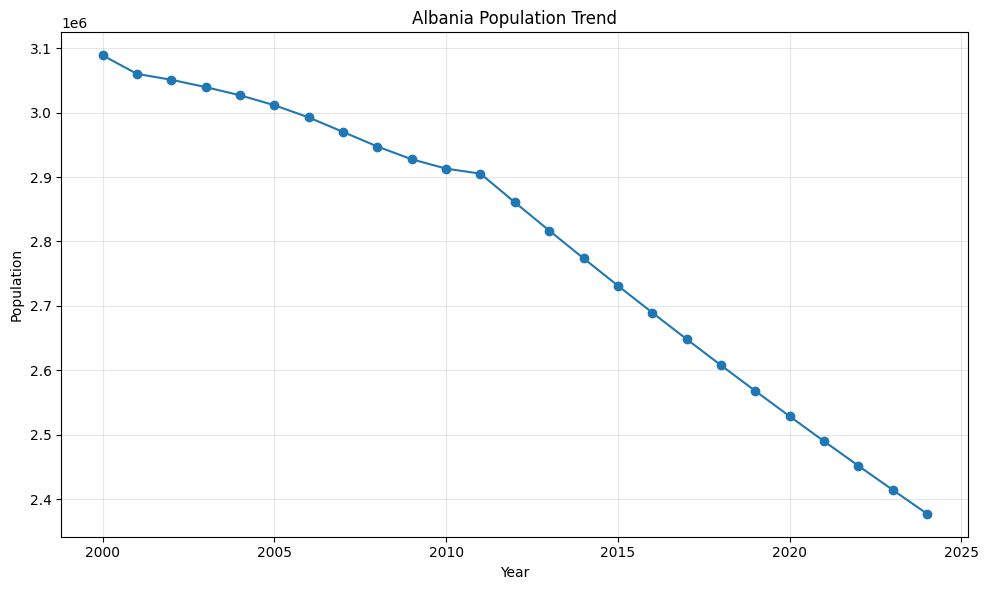

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(
    population_data["year"],
    population_data["population_total"],
    marker="o"
)

plt.title("Albania Population Trend")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "population_trend.png", dpi=300)
plt.show()

## Population Change Since 2000

In [9]:
population_2000 = population_data.loc[
    population_data["year"] == 2000, 
    "population_total"
]

latest_population_row = population_data.sort_values("year").dropna().tail(1)

if not population_2000.empty and not latest_population_row.empty:
    population_2000_value = population_2000.iloc[0]
    latest_year = int(latest_population_row["year"].iloc[0])
    latest_population = latest_population_row["population_total"].iloc[0]
    
    population_change = latest_population - population_2000_value
    population_change_percent = (population_change / population_2000_value) * 100
    
    print("Population in 2000:", round(population_2000_value))
    print("Latest year:", latest_year)
    print("Latest population:", round(latest_population))
    print("Population change:", round(population_change))
    print("Population change %:", round(population_change_percent, 2))
else:
    print("Population data for 2000 or latest year is missing.")

Population in 2000: 3089027
Latest year: 2024
Latest population: 2377128
Population change: -711899
Population change %: -23.05


## Net Migration Trend

World Bank net migration is used to analyze Albania-level migration pressure.
Negative values indicate that more people are leaving than entering over the measured period.

In [10]:
net_migration_data = master[
    ["year", "net_migration", "net_migration_rate_per_1000"]
].dropna(subset=["net_migration"]).copy()

net_migration_data.head()

,year,net_migration,net_migration_rate_per_1000
0,2000,-60531.0,-19.595491
1,2001,-48070.0,-15.708262
2,2002,-45178.0,-14.807556
3,2003,-48517.0,-15.961556
4,2004,-48654.0,-16.073664


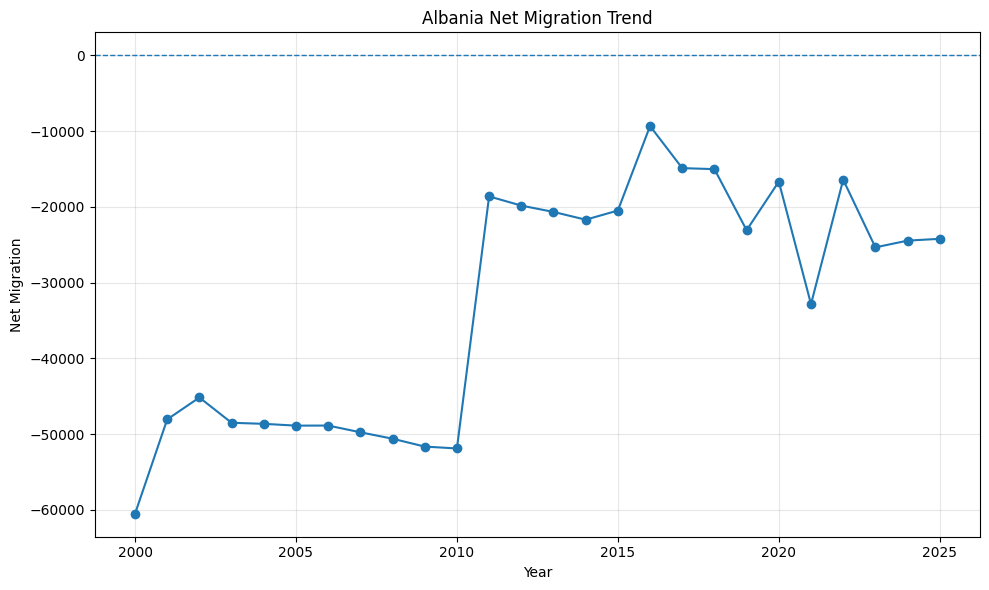

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    net_migration_data["year"],
    net_migration_data["net_migration"],
    marker="o"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Albania Net Migration Trend")
plt.xlabel("Year")
plt.ylabel("Net Migration")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "migration_trend.png", dpi=300)
plt.show()

## Find Strongest Migration Pressure Years

In [12]:
strongest_negative_migration_years = (
    net_migration_data
    .sort_values("net_migration")
    .head(10)
)

strongest_negative_migration_years

,year,net_migration,net_migration_rate_per_1000
0,2000,-60531.0,-19.595491
10,2010,-51907.0,-17.818958
9,2009,-51657.0,-17.645317
8,2008,-50619.0,-17.174621
7,2007,-49770.0,-16.757480
5,2005,-48893.0,-16.235501
6,2006,-48882.0,-16.334581
4,2004,-48654.0,-16.073664
3,2003,-48517.0,-15.961556
1,2001,-48070.0,-15.708262


## GDP Growth and Unemployment Trend

This section compares GDP growth and unemployment because economic conditions are possible drivers of migration pressure.

In [13]:
economy_employment = master[
    [
        "year",
        "gdp_growth_annual_percent",
        "gdp_per_capita_current_usd",
        "unemployment_total_percent"
    ]
].copy()

economy_employment.head()

,year,gdp_growth_annual_percent,gdp_per_capita_current_usd,unemployment_total_percent
0,2000,7.462859,1160.420471,19.023
1,2001,8.863731,1326.416524,18.570
2,2002,4.628396,1479.838846,17.891
3,2003,5.333264,1908.699007,16.985
4,2004,5.266262,2446.909499,16.306


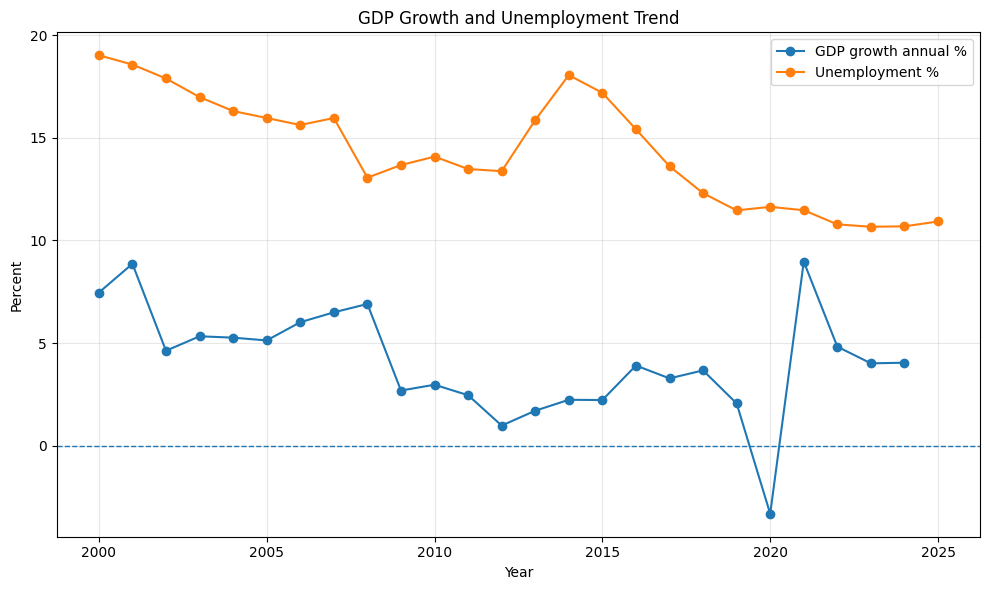

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    economy_employment["year"],
    economy_employment["gdp_growth_annual_percent"],
    marker="o",
    label="GDP growth annual %"
)

plt.plot(
    economy_employment["year"],
    economy_employment["unemployment_total_percent"],
    marker="o",
    label="Unemployment %"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("GDP Growth and Unemployment Trend")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "gdp_unemployment_trend.png", dpi=300)
plt.show()

## Eurostat Migration Flows

Eurostat immigration data shows Albanian citizens arriving in European reporting countries.  
This is not exactly the same as direct emigration from Albania, but it is useful as a proxy for Albanian international mobility.

In [15]:
migration_yearly = (
    migration_flows
    .groupby(["year", "flow_type"], as_index=False)["value"]
    .sum()
)

migration_yearly.head()

,year,flow_type,value
0,2015,emigration,6078939.0
1,2015,immigration,10169201.0
2,2016,emigration,6625508.0
3,2016,immigration,9341215.0
4,2017,emigration,6565859.0


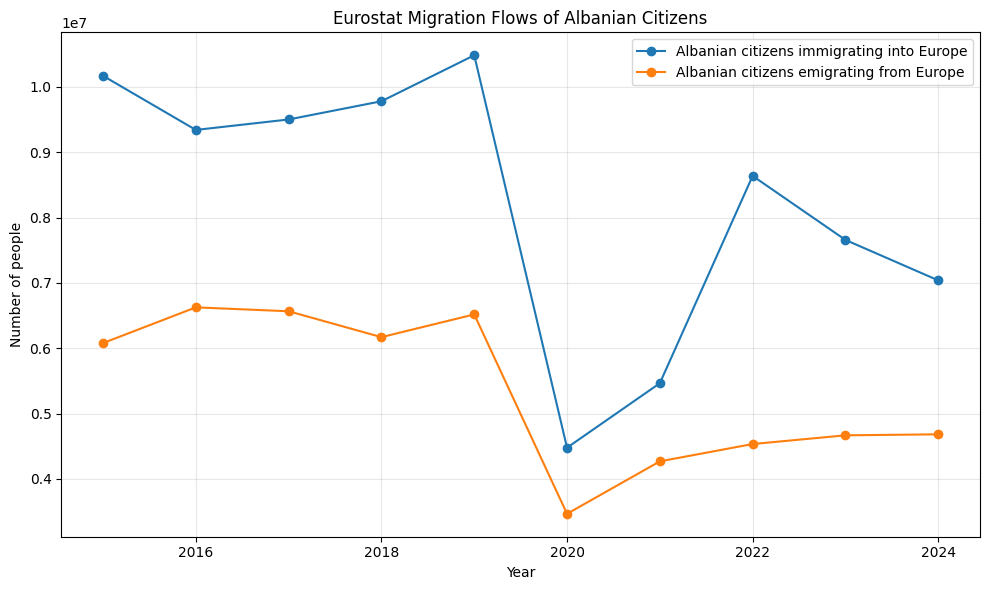

In [16]:
migration_yearly_wide = migration_yearly.pivot_table(
    index="year",
    columns="flow_type",
    values="value",
    aggfunc="sum"
).reset_index()

migration_yearly_wide.columns.name = None

plt.figure(figsize=(10, 6))

if "immigration" in migration_yearly_wide.columns:
    plt.plot(
        migration_yearly_wide["year"],
        migration_yearly_wide["immigration"],
        marker="o",
        label="Albanian citizens immigrating into Europe"
    )

if "emigration" in migration_yearly_wide.columns:
    plt.plot(
        migration_yearly_wide["year"],
        migration_yearly_wide["emigration"],
        marker="o",
        label="Albanian citizens emigrating from Europe"
    )

plt.title("Eurostat Migration Flows of Albanian Citizens")
plt.xlabel("Year")
plt.ylabel("Number of people")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "eurostat_migration_flows.png", dpi=300)
plt.show()

## Top European Destination Countries

This section identifies the main European reporting countries where Albanian citizens are recorded as immigrating.

In [17]:
top_destinations = (
    migration_flows[
        migration_flows["flow_type"] == "immigration"
    ]
    .groupby("reporting_country", as_index=False)["value"]
    .sum()
    .sort_values("value", ascending=False)
    .head(10)
)

top_destinations

,reporting_country,value
10,Germany,16828903.0
31,Spain,11146851.0
9,France,6548079.0
34,United Kingdom,6299026.0
15,Italy,5578003.0
26,Poland,3833529.0
28,Romania,3703357.0
23,Netherlands,3381532.0
33,Switzerland,2514905.0
1,Belgium,2261534.0


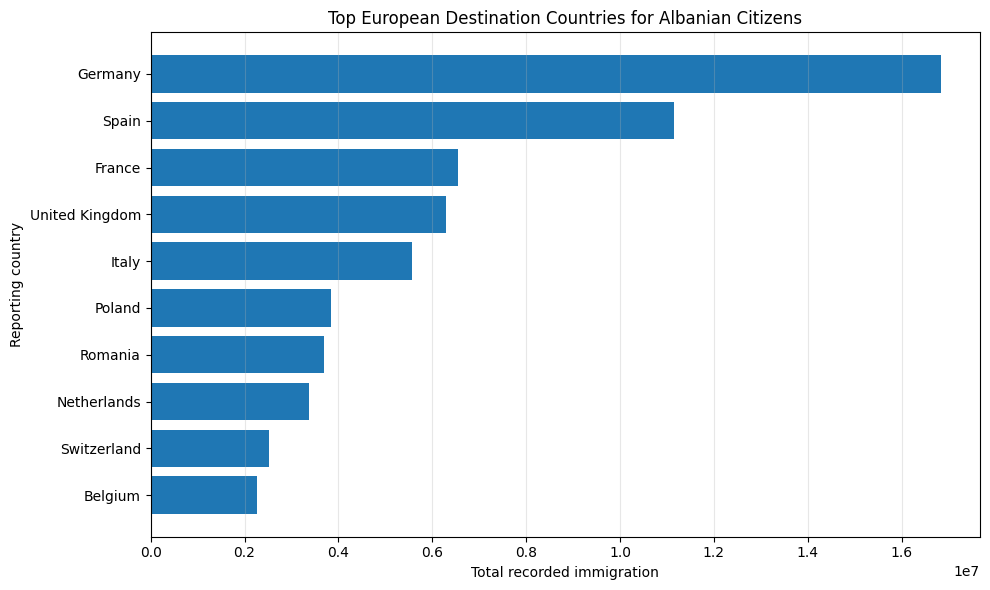

In [18]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_destinations["reporting_country"],
    top_destinations["value"]
)

plt.gca().invert_yaxis()

plt.title("Top European Destination Countries for Albanian Citizens")
plt.xlabel("Total recorded immigration")
plt.ylabel("Reporting country")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "top_migration_destinations.png", dpi=300)
plt.show()

## Residence Permits by Reason

This section analyzes why Albanian citizens receive first residence permits in European countries.

Important: this analysis uses reason subcategories only, not TOTAL, to avoid double counting.

In [19]:
permits_by_reason = (
    residence_reason
    .groupby(["year", "reason"], as_index=False)["value"]
    .sum()
)

permits_by_reason.head()

,year,reason,value
0,2008,Education reasons,407006
1,2008,Employment reasons,737366
2,2008,Family reasons,681431
3,2009,Education reasons,470809
4,2009,Employment reasons,618918


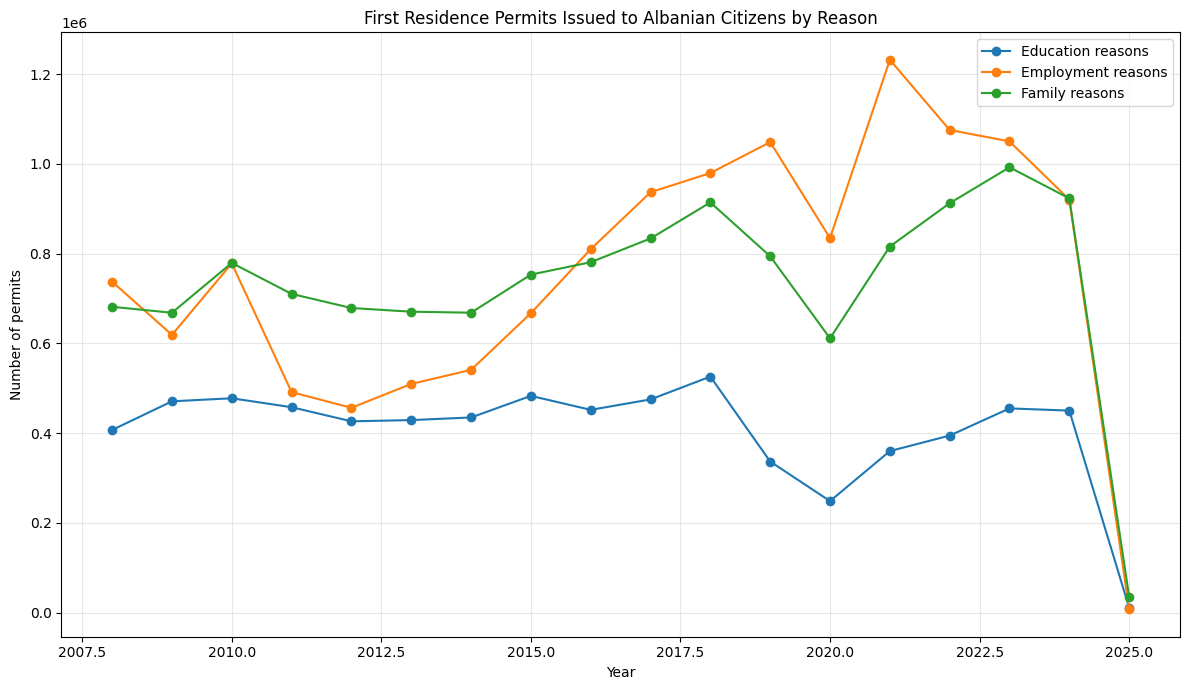

In [20]:
permits_pivot = permits_by_reason.pivot_table(
    index="year",
    columns="reason",
    values="value",
    aggfunc="sum"
).fillna(0)

plt.figure(figsize=(12, 7))

for column in permits_pivot.columns:
    plt.plot(
        permits_pivot.index,
        permits_pivot[column],
        marker="o",
        label=column
    )

plt.title("First Residence Permits Issued to Albanian Citizens by Reason")
plt.xlabel("Year")
plt.ylabel("Number of permits")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "residence_permits_by_reason.png", dpi=300)
plt.show()

## Basic Correlation Matrix

This section gives an early view of relationships between population, migration, unemployment, GDP growth, and residence permits.

Correlation does not prove causation.  
The statistical analysis notebook will later test relationships more formally using Pearson and Spearman correlations.

In [21]:
correlation_columns = [
    "population_total",
    "population_growth_annual_percent",
    "net_migration",
    "net_migration_rate_per_1000",
    "gdp_growth_annual_percent",
    "gdp_per_capita_current_usd",
    "unemployment_total_percent",
    "remittances_percent_gdp",
    "fdi_percent_gdp",
    "total_first_residence_permits",
    "residence_permits_per_100k_population",
    "employment_permit_share",
    "education_permit_share",
    "family_permit_share",
    "migration_pressure_index"
]

available_corr_cols = [
    col for col in correlation_columns 
    if col in master.columns
]

corr_data = master[available_corr_cols].copy()
corr_matrix = corr_data.corr(numeric_only=True)

corr_matrix

,population_total,population_growth_annual_percent,net_migration,net_migration_rate_per_1000,gdp_growth_annual_percent,gdp_per_capita_current_usd,unemployment_total_percent,remittances_percent_gdp,fdi_percent_gdp,total_first_residence_permits,residence_permits_per_100k_population,employment_permit_share,education_permit_share,family_permit_share,migration_pressure_index
population_total,1.000000,0.818885,-0.739586,-0.651739,0.330350,-0.924142,0.794893,0.931443,-0.392221,-0.767687,-0.873354,-0.569634,0.849042,0.501200,-0.892295
population_growth_annual_percent,0.818885,1.000000,-0.784913,-0.737164,0.351229,-0.662005,0.473897,0.836243,-0.478926,-0.445745,-0.518403,-0.206871,0.557470,0.498949,-0.765690
net_migration,-0.739586,-0.784913,1.000000,0.991688,-0.579117,0.575317,-0.485657,-0.840278,0.473584,0.108500,0.280605,-0.081588,-0.239806,-0.012301,0.737843
net_migration_rate_per_1000,-0.651739,-0.737164,0.991688,1.000000,-0.593236,0.473625,-0.386782,-0.771786,0.451956,0.110467,0.160637,-0.174756,-0.125868,-0.013676,0.663856
gdp_growth_annual_percent,0.330350,0.351229,-0.579117,-0.593236,1.000000,-0.249483,0.290205,0.487442,-0.438215,0.561442,0.469574,0.156077,-0.197316,-0.415732,-0.360053
gdp_per_capita_current_usd,-0.924142,-0.662005,0.575317,0.473625,-0.249483,1.000000,-0.846305,-0.867608,0.397899,0.708309,0.810646,0.355807,-0.648664,-0.291574,0.849923
unemployment_total_percent,0.794893,0.473897,-0.485657,-0.386782,0.290205,-0.846305,1.000000,0.747916,-0.397471,-0.091768,-0.588963,-0.290391,0.659680,-0.152896,-0.772903
remittances_percent_gdp,0.931443,0.836243,-0.840278,-0.771786,0.487442,-0.867608,0.747916,1.000000,-0.568708,-0.624431,-0.733329,-0.349568,0.678247,0.335721,-0.908261
fdi_percent_gdp,-0.392221,-0.478926,0.473584,0.451956,-0.438215,0.397899,-0.397471,-0.568708,1.000000,-0.499202,-0.617206,-0.456687,0.626075,0.097750,0.702761
total_first_residence_permits,-0.767687,-0.445745,0.108500,0.110467,0.561442,0.708309,-0.091768,-0.624431,-0.499202,1.000000,0.980684,0.710379,-0.291057,-0.881022,0.980692


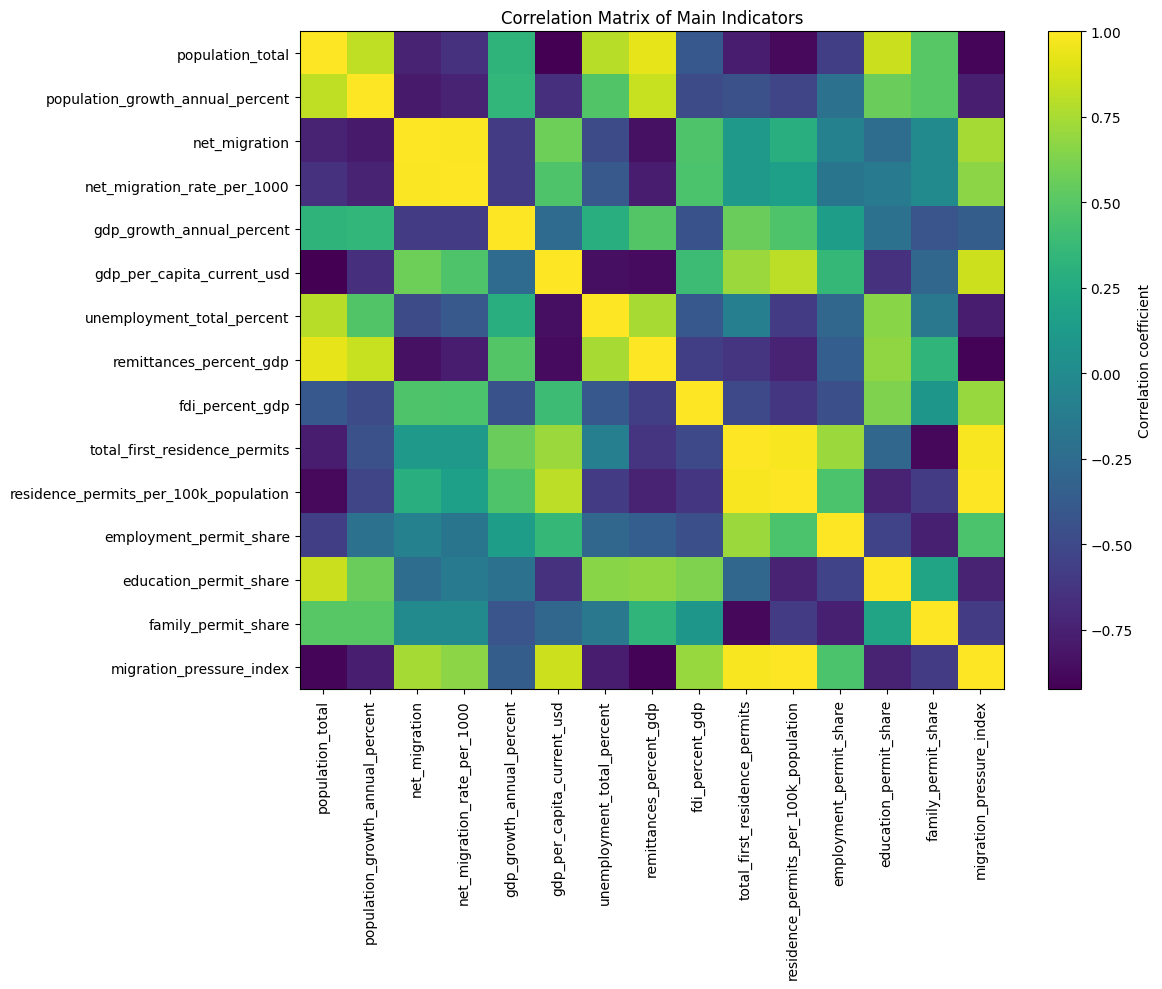

In [22]:
plt.figure(figsize=(12, 10))

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation coefficient")

plt.xticks(
    ticks=range(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(corr_matrix.index)),
    labels=corr_matrix.index
)

plt.title("Correlation Matrix of Main Indicators")
plt.tight_layout()

plt.savefig(VISUALS_DIR / "correlation_matrix.png", dpi=300)
plt.show()

## Generate EDA Summary Report

In [23]:
# Basic calculated values for summary

summary_lines = []

summary_lines.append("# Exploratory Data Analysis Summary")
summary_lines.append("")
summary_lines.append("## Project")
summary_lines.append("")
summary_lines.append("Albania’s Brain Drain: A Data-Driven Analysis of Migration, Employment and Economic Development")
summary_lines.append("")
summary_lines.append("## Purpose")
summary_lines.append("")
summary_lines.append("This report summarizes the main descriptive patterns found during exploratory data analysis.")
summary_lines.append("")

# Population summary
if not population_2000.empty and not latest_population_row.empty:
    summary_lines.append("## Population")
    summary_lines.append("")
    summary_lines.append(f"- Population in 2000: {population_2000_value:,.0f}")
    summary_lines.append(f"- Latest available population year: {latest_year}")
    summary_lines.append(f"- Latest available population: {latest_population:,.0f}")
    summary_lines.append(f"- Population change since 2000: {population_change:,.0f}")
    summary_lines.append(f"- Population change percentage since 2000: {population_change_percent:.2f}%")
    summary_lines.append("")

# Net migration summary
if not net_migration_data.empty:
    worst_migration = net_migration_data.sort_values("net_migration").head(1)
    worst_year = int(worst_migration["year"].iloc[0])
    worst_value = worst_migration["net_migration"].iloc[0]
    
    summary_lines.append("## Net Migration")
    summary_lines.append("")
    summary_lines.append(f"- Strongest negative net migration year in the dataset: {worst_year}")
    summary_lines.append(f"- Net migration value in that year: {worst_value:,.0f}")
    summary_lines.append("")

# Top destinations
if not top_destinations.empty:
    summary_lines.append("## Top Destination Countries")
    summary_lines.append("")
    for _, row in top_destinations.head(5).iterrows():
        summary_lines.append(f"- {row['reporting_country']}: {row['value']:,.0f}")
    summary_lines.append("")

# Residence permits
if not permits_by_reason.empty:
    latest_permit_year = int(permits_by_reason["year"].max())
    latest_permits = permits_by_reason[
        permits_by_reason["year"] == latest_permit_year
    ].sort_values("value", ascending=False)
    
    summary_lines.append("## Residence Permits by Reason")
    summary_lines.append("")
    summary_lines.append(f"Latest available permit year: {latest_permit_year}")
    summary_lines.append("")
    
    for _, row in latest_permits.head(5).iterrows():
        summary_lines.append(f"- {row['reason']}: {row['value']:,.0f}")
    summary_lines.append("")

summary_lines.append("## Important Limitations")
summary_lines.append("")
summary_lines.append("- Eurostat immigration data shows Albanian citizens arriving in European reporting countries, not direct emigration from Albania.")
summary_lines.append("- Residence permit TOTAL categories were separated from reason subcategories to avoid double counting.")
summary_lines.append("- Correlation analysis does not prove causation.")
summary_lines.append("- Some indicators have missing values depending on the source and year.")
summary_lines.append("")

summary_lines.append("## Visuals Created")
summary_lines.append("")
summary_lines.append("- population_trend.png")
summary_lines.append("- migration_trend.png")
summary_lines.append("- gdp_unemployment_trend.png")
summary_lines.append("- eurostat_migration_flows.png")
summary_lines.append("- top_migration_destinations.png")
summary_lines.append("- residence_permits_by_reason.png")
summary_lines.append("- correlation_matrix.png")

eda_report_path = REPORTS_DIR / "eda_summary.md"

with open(eda_report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print("EDA summary saved to:", eda_report_path)

EDA summary saved to: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\reports\eda_summary.md
